<a href="https://colab.research.google.com/github/77marco/Challenge-TelecomX-AnalisisDeEvasionDeClientes-Parte2/blob/main/TelecomX_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🔧 Preparación de los Datos

### Extracción del Archivo Tratado

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Ruta de acceso que tengo desde el explorador de archivos de google drive donde se guardo el archivo solicitado
ruta = '/content/drive/MyDrive/Data Science /Alura Latam/Cursos/Estadistica y Machine learning/Challenge Telecom X: análisis de evasión de clientes - Parte 2/datos_tratados.csv'

# Cargar el archivo CSV en un DataFrame
df_telecom = pd.read_csv(ruta)

# Visualizar las primeras 5 filas para confirmar que todo está en orden
df_telecom.head()

,customerID,Evasion,gender,SeniorCitizen,Partner,Dependents,Meses_Contrato,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Cargos_Mensuales,Cuentas_Diarias,Cargos_Totales
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,2.19,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,2.00,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,2.46,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,3.27,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,2.80,267.40


### Eliminación de Columnas Irrelevantes

In [4]:
# Eliminar la columna 'customerID'
df_telecom = df_telecom.drop(columns=['customerID'])

# Mostrar las primeras filas y la información general para confirmar
print(df_telecom.head())
print("\n--- Información del DataFrame ---")
df_telecom.info()

   Evasion  gender  SeniorCitizen  Partner  Dependents  Meses_Contrato  \
0        0  Female              0        1           1               9   
1        0    Male              0        0           0               9   
2        1    Male              0        0           0               4   
3        1    Male              1        1           0              13   
4        1  Female              1        1           0               3   

   PhoneService MultipleLines InternetService OnlineSecurity  ...  \
0             1            No             DSL             No  ...   
1             1           Yes             DSL             No  ...   
2             1            No     Fiber optic             No  ...   
3             1            No     Fiber optic             No  ...   
4             1            No     Fiber optic             No  ...   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes         Yes              No    

### Encoding

In [5]:
# Aplicar One-Hot Encoding a todas las variables categóricas
# Usamos drop_first=True para evitar la "trampa de las variables ficticias" (multicolinealidad)
# Usamos dtype=int para que los resultados sean 0 y 1 en lugar de True y False
df_telecom_encoded = pd.get_dummies(df_telecom, drop_first=True, dtype=int)

# Mostrar cómo quedó el nuevo DataFrame
print(df_telecom_encoded.head())

# Ver el nuevo resumen de columnas y tipos de datos
print("\n--- Información del DataFrame Post-Encoding ---")
df_telecom_encoded.info()

   Evasion  SeniorCitizen  Partner  Dependents  Meses_Contrato  PhoneService  \
0        0              0        1           1               9             1   
1        0              0        0           0               9             1   
2        1              0        0           0               4             1   
3        1              1        1           0              13             1   
4        1              1        1           0               3             1   

   PaperlessBilling  Cargos_Mensuales  Cuentas_Diarias  Cargos_Totales  ...  \
0                 1              65.6             2.19          593.30  ...   
1                 0              59.9             2.00          542.40  ...   
2                 1              73.9             2.46          280.85  ...   
3                 1              98.0             3.27         1237.85  ...   
4                 1              83.9             2.80          267.40  ...   

   OnlineBackup_Yes  DeviceProtection_Yes  T

### Verificación de la Proporción de Cancelación (Churn)

In [6]:
# Contar la cantidad exacta de clientes en cada clase (0 = Retenidos, 1 = Cancelaron)
conteo_churn = df_telecom_encoded['Evasion'].value_counts()
print("--- Cantidad de clientes por clase ---")
print(conteo_churn)

# Calcular el porcentaje que representa cada clase
proporcion_churn = df_telecom_encoded['Evasion'].value_counts(normalize=True) * 100
print("\n--- Proporción de clientes por clase (%) ---")
print(proporcion_churn)

--- Cantidad de clientes por clase ---
Evasion
0    5174
1    1869
Name: count, dtype: int64

--- Proporción de clientes por clase (%) ---
Evasion
0    73.463013
1    26.536987
Name: proportion, dtype: float64


### Balanceo de Clases (opcional)

In [7]:
# Importar la librería necesaria para SMOTE
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Separar las variables predictoras (X) de la variable a predecir (y)
X = df_telecom_encoded.drop('Evasion', axis=1)
y = df_telecom_encoded['Evasion']

# 2. Inicializar SMOTE (fijamos el random_state para que el resultado sea reproducible)
smote = SMOTE(random_state=42)

# 3. Aplicar el algoritmo para generar los nuevos datos sintéticos
X_res, y_res = smote.fit_resample(X, y)

# 4. Volver a unir todo en un solo DataFrame para los siguientes pasos
df_telecom_balanceado = pd.concat([X_res, y_res], axis=1)

# Verificar el resultado final
print("--- Nueva distribución de clases tras aplicar SMOTE ---")
print(df_telecom_balanceado['Evasion'].value_counts())

--- Nueva distribución de clases tras aplicar SMOTE ---
Evasion
0    5174
1    5174
Name: count, dtype: int64


### Normalización o Estandarización (si es necesario)

In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Crear una copia del DataFrame balanceado para mantener el historial limpio
df_telecom_escalado = df_telecom_balanceado.copy()

# 2. Definir cuáles son las columnas con valores numéricos grandes/continuos
columnas_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cuentas_Diarias', 'Cargos_Totales']

# 3. Inicializar el escalador
scaler = StandardScaler()

# 4. Aplicar la transformación solo a esas columnas específicas
df_telecom_escalado[columnas_numericas] = scaler.fit_transform(df_telecom_escalado[columnas_numericas])

# 5. Visualizar cómo quedaron los datos transformados
print("--- Variables Numéricas Estandarizadas ---")
print(df_telecom_escalado[columnas_numericas].head())

--- Variables Numéricas Estandarizadas ---
   Meses_Contrato  Cargos_Mensuales  Cuentas_Diarias  Cargos_Totales
0       -0.777727         -0.084757        -0.081271       -0.664633
1       -0.777727         -0.283260        -0.279752       -0.687908
2       -0.986176          0.204290         0.200781       -0.807503
3       -0.610968          1.043573         1.046936       -0.369908
4       -1.027865          0.552540         0.555957       -0.813654


#📊 Correlación y Selección de Variables

### Análisis de Correlación

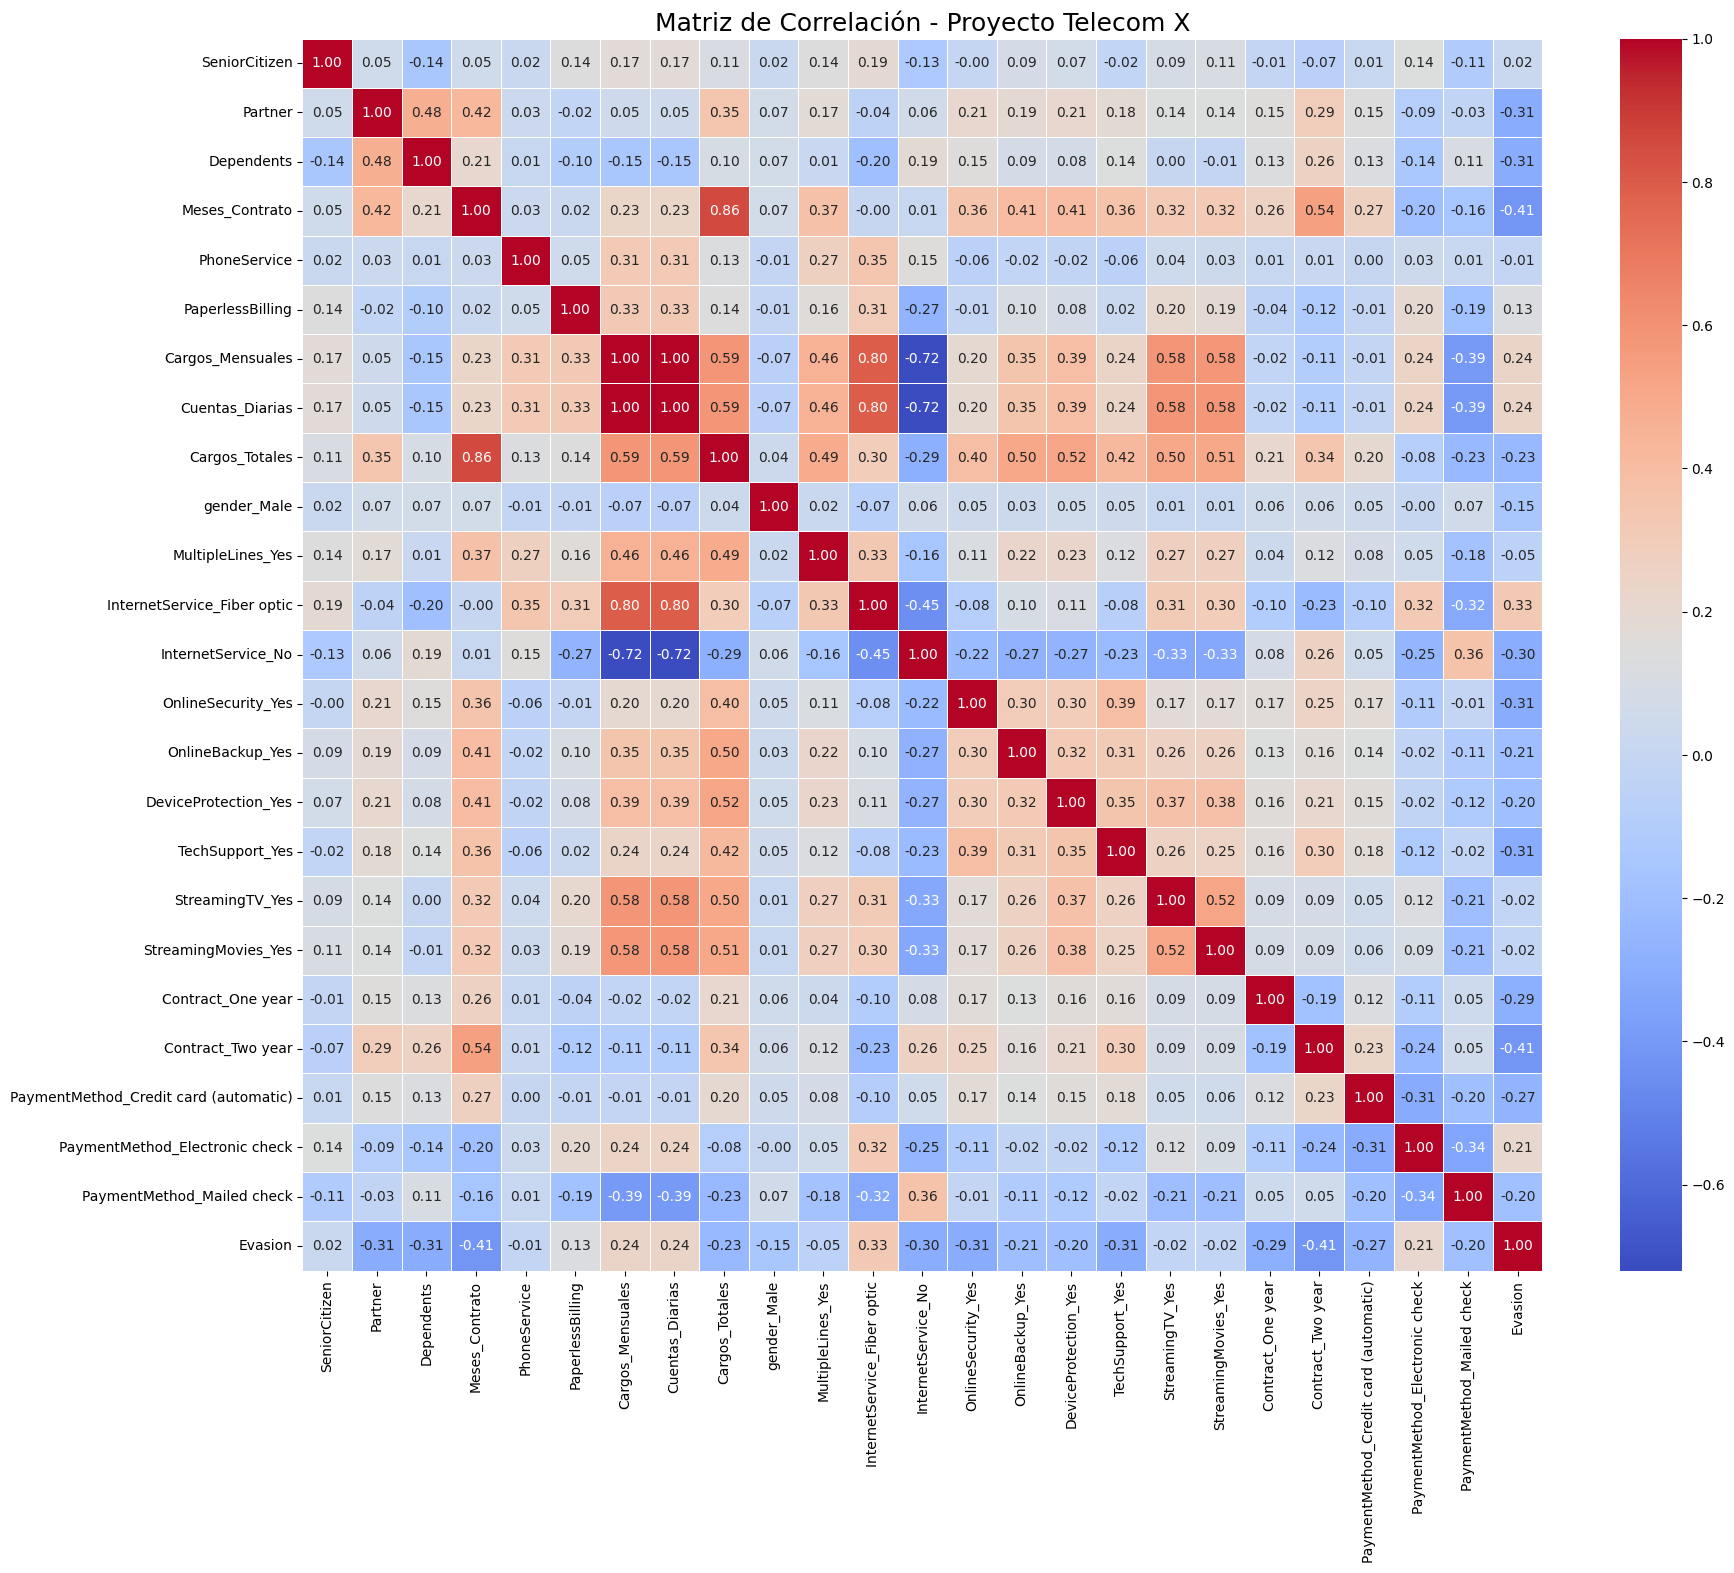


--- Top Variables correlacionadas con la Evasión ---
Evasion                                  1.000000
InternetService_Fiber optic              0.327297
Cuentas_Diarias                          0.235794
Cargos_Mensuales                         0.235719
PaymentMethod_Electronic check           0.211195
PaperlessBilling                         0.125708
SeniorCitizen                            0.019489
PhoneService                            -0.013040
StreamingTV_Yes                         -0.016935
StreamingMovies_Yes                     -0.019320
MultipleLines_Yes                       -0.051439
gender_Male                             -0.153763
PaymentMethod_Mailed check              -0.195283
DeviceProtection_Yes                    -0.200083
OnlineBackup_Yes                        -0.205717
Cargos_Totales                          -0.230041
PaymentMethod_Credit card (automatic)   -0.267995
Contract_One year                       -0.290215
InternetService_No                      -0.301

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la matriz de correlación usando el DataFrame ya escalado
matriz_correlacion = df_telecom_escalado.corr()

# 2. Configurar el tamaño de la figura para que se vea claro (tenemos 25 columnas)
plt.figure(figsize=(20, 16))

# 3. Generar el Mapa de Calor (Heatmap)
# annot=True muestra los números, cmap='coolwarm' usa rojo para correlaciones positivas y azul para negativas
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Proyecto Telecom X', fontsize=18)
plt.show()

# 4. Extraer y ordenar específicamente la correlación de todas las variables frente a 'Evasion'
print("\n--- Top Variables correlacionadas con la Evasión ---")
correlacion_evasion = matriz_correlacion['Evasion'].sort_values(ascending=False)
print(correlacion_evasion)

### Análisis Dirigido

#📌 Modelado Predictivo

### Separación de Datos

### Creación de Modelos

### Evaluación de los Modelos

#📄Interpretación y Conclusiones

### Análisis de la Importancia de las Variables

### Conclusión